Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Loading the dataset

In [2]:
df = pd.read_csv("/content/mcdonaldata.csv")

Explore

In [3]:
df.head()

,Unnamed: 0,item,servesize,calories,protien,totalfat,satfat,transfat,cholestrol,carbs,sugar,addedsugar,sodium,menu
0,0,McVeggie Burger,168,402,10.24,13.83,5.34,0.16,2.49,56.54,7.90,4.49,706.13,regular
1,1,McAloo Tikki Burger,146,339,8.50,11.31,4.27,0.20,1.47,5.27,7.05,4.07,545.34,regular
2,2,McSpicy Paneer Burger,199,652,20.29,39.45,17.12,0.18,21.85,52.33,8.35,5.27,1074.58,regular
3,3,Spicy Paneer Wrap,250,674,20.96,39.10,19.73,0.26,40.93,59.27,3.50,1.08,1087.46,regular
4,4,American Veg Burger,177,512,15.30,23.45,10.51,0.17,25.24,56.96,7.85,4.76,1051.24,regular


In [5]:
# Check dataset dimensions
print("Dataset Shape:", df.shape)

Dataset Shape: (141, 14)


In [6]:
# Check column names
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['Unnamed: 0', 'item', 'servesize', 'calories', 'protien', 'totalfat', 'satfat', 'transfat', 'cholestrol', 'carbs', 'sugar', 'addedsugar', 'sodium', 'menu']


In [8]:
# Check data types and non-null values
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  141 non-null    int64  
 1   item        141 non-null    object 
 2   servesize   141 non-null    object 
 3   calories    141 non-null    object 
 4   protien     141 non-null    float64
 5   totalfat    141 non-null    float64
 6   satfat      141 non-null    float64
 7   transfat    141 non-null    float64
 8   cholestrol  141 non-null    float64
 9   carbs       141 non-null    float64
 10  sugar       141 non-null    float64
 11  addedsugar  141 non-null    float64
 12  sodium      141 non-null    float64
 13  menu        141 non-null    object 
dtypes: float64(9), int64(1), object(4)
memory usage: 15.6+ KB


In [9]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Unnamed: 0    0
item          0
servesize     0
calories      0
protien       0
totalfat      0
satfat        0
transfat      0
cholestrol    0
carbs         0
sugar         0
addedsugar    0
sodium        0
menu          0
dtype: int64


Data cleaning

In [10]:
# Remove unnecessary index column
df.drop(columns=['Unnamed: 0'], inplace=True)

In [11]:
# Convert calories to numeric
df['calories'] = pd.to_numeric(df['calories'], errors='coerce')


In [12]:
# Correct column names
df.rename(columns={
    'protien': 'protein',
    'cholestrol': 'cholesterol'
}, inplace=True)

In [14]:
print("Dataset Shape:", df.shape)

Dataset Shape: (141, 13)


In [15]:
print("\nUpdated Columns:")
print(df.columns.tolist())


Updated Columns:
['item', 'servesize', 'calories', 'protein', 'totalfat', 'satfat', 'transfat', 'cholesterol', 'carbs', 'sugar', 'addedsugar', 'sodium', 'menu']


In [16]:
print("\nData Types:")
print(df.dtypes)


Data Types:
item            object
servesize       object
calories       float64
protein        float64
totalfat       float64
satfat         float64
transfat       float64
cholesterol    float64
carbs          float64
sugar          float64
addedsugar     float64
sodium         float64
menu            object
dtype: object


In [17]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
item           0
servesize      0
calories       7
protein        0
totalfat       0
satfat         0
transfat       0
cholesterol    0
carbs          0
sugar          0
addedsugar     0
sodium         0
menu           0
dtype: int64


The dataset contains 7 missing values

In [18]:
# Display rows with missing calories
missing_calories = df[df['calories'].isnull()]

print("Number of missing calorie values:", len(missing_calories))

missing_calories[['item', 'menu', 'servesize', 'calories']]

Number of missing calorie values: 7


,item,menu,servesize,calories
105,American Triple Cheese Veg,gourmet,207,NaN
106,Cheese Lava Burger,gourmet,240,NaN
107,Chicken Cheese Lava Burger,gourmet,307,NaN
108,Chunky Chipotle American Burger Chicken,gourmet,301,NaN
109,McSpicy Premium Chicken Burger,gourmet,264.5,NaN
110,McSpicy Premium Veg Burger,gourmet,212.5,NaN
111,Piri piri Mc Spicy Chicken Burger,gourmet,228,NaN


In [19]:
# Display all columns for the affected rows
df.loc[105:111]

,item,servesize,calories,protein,totalfat,satfat,transfat,cholesterol,carbs,sugar,addedsugar,sodium,menu
105,American Triple Cheese Veg,207,NaN,19.54,23.16,14.78,0.19,48.74,56.24,7.90,3.84,1174.27,gourmet
106,Cheese Lava Burger,240,NaN,14.99,33.48,14.12,0.21,33.21,74.25,16.27,10.01,1153.99,gourmet
107,Chicken Cheese Lava Burger,307,NaN,27.37,45.18,17.00,0.27,73.11,76.03,16.75,10.01,1745.04,gourmet
108,Chunky Chipotle American Burger Chicken,301,NaN,39.47,31.51,9.54,0.26,110.37,46.24,9.16,6.32,1906.27,gourmet
109,McSpicy Premium Chicken Burger,264.5,NaN,31.49,34.65,15.55,0.24,302.61,43.60,6.07,2.64,1614.88,gourmet
110,McSpicy Premium Veg Burger,212.5,NaN,22.44,39.21,20.46,0.20,43.68,46.00,7.57,3.28,1446.87,gourmet
111,Piri piri Mc Spicy Chicken Burger,228,NaN,25.63,17.30,4.01,0.19,64.19,43.29,9.29,6.32,1229.86,gourmet


In [20]:
# Create a separate dataset for calorie analysis
calorie_df = df.dropna(subset=['calories']).copy()

print("Original dataset:", df.shape)
print("Dataset for calorie analysis:", calorie_df.shape)
print("Missing calories:", calorie_df['calories'].isnull().sum())

Original dataset: (141, 13)
Dataset for calorie analysis: (134, 13)
Missing calories: 0


/tmp/ipykernel_1607/2272645236.py:9: UserWarning: Glyph 153 (\x99) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 153 (\x99) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


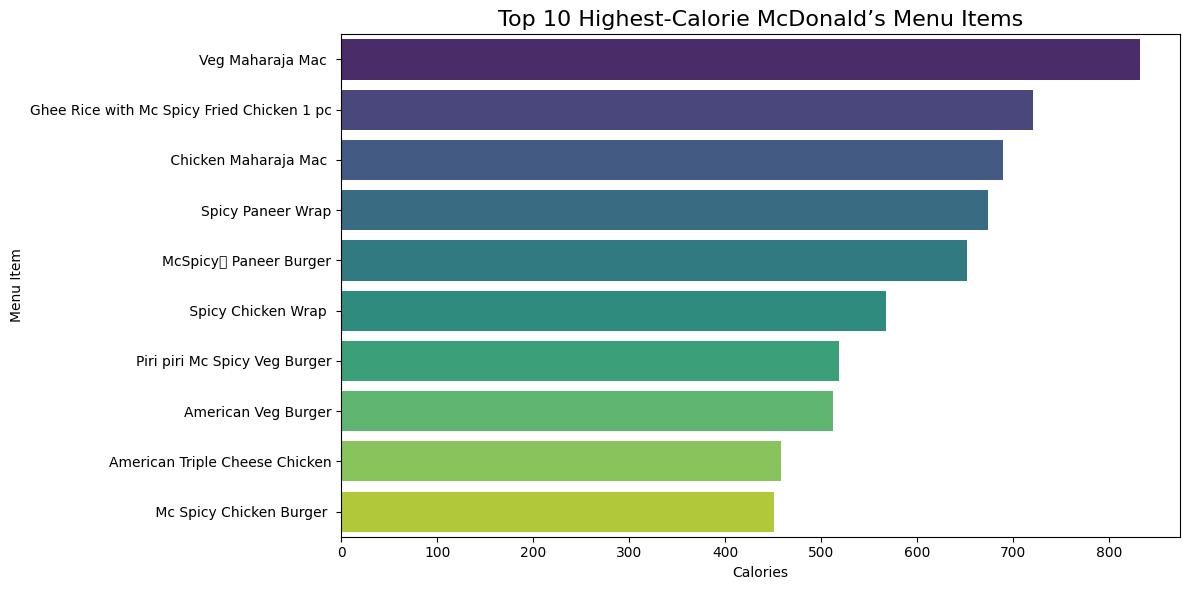

In [21]:
top_10 = calorie_df.nlargest(10, 'calories')

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10, x='calories', y='item', hue='item', palette='viridis', legend=False)

plt.title('Top 10 Highest-Calorie McDonald’s Menu Items', fontsize=16)
plt.xlabel('Calories')
plt.ylabel('Menu Item')
plt.tight_layout()
plt.show()

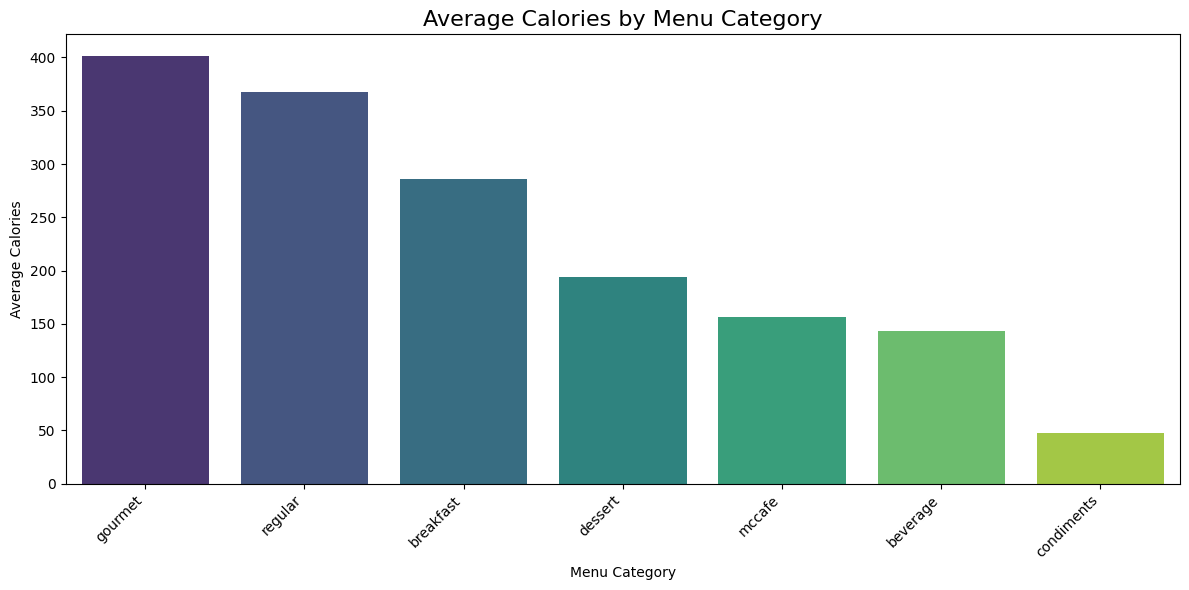

In [22]:
# Calculate average calories by menu category
avg_calories = (
    calorie_df.groupby('menu')['calories']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Create bar chart
plt.figure(figsize=(12, 6))

sns.barplot(
    data=avg_calories,
    x='menu',
    y='calories',
    hue='menu',
    palette='viridis',
    legend=False
)

plt.title('Average Calories by Menu Category', fontsize=16)
plt.xlabel('Menu Category')
plt.ylabel('Average Calories')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

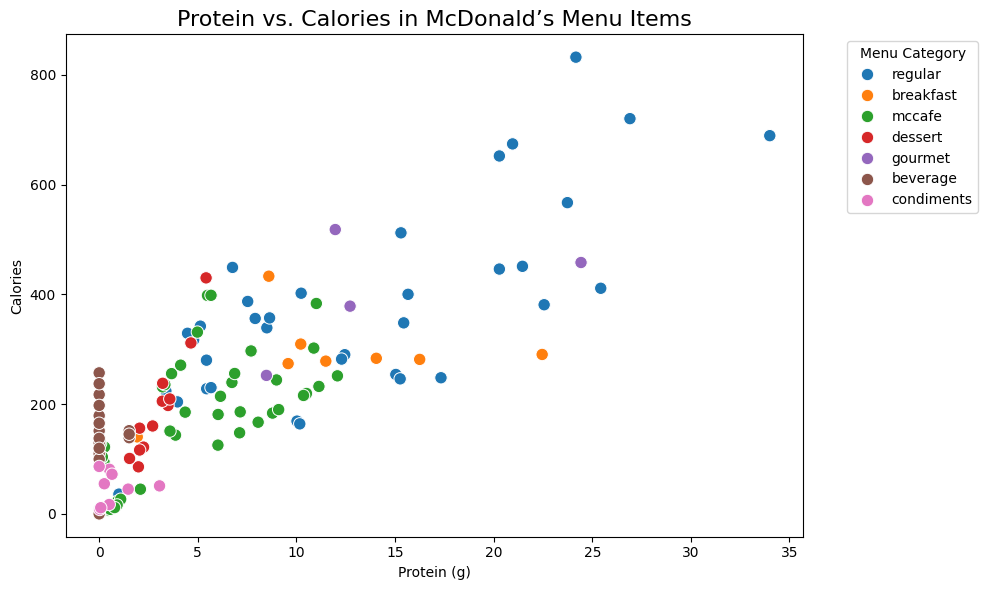

In [23]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=calorie_df,
    x='protein',
    y='calories',
    hue='menu',
    s=80
)

plt.title('Protein vs. Calories in McDonald’s Menu Items', fontsize=16)
plt.xlabel('Protein (g)')
plt.ylabel('Calories')
plt.legend(title='Menu Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

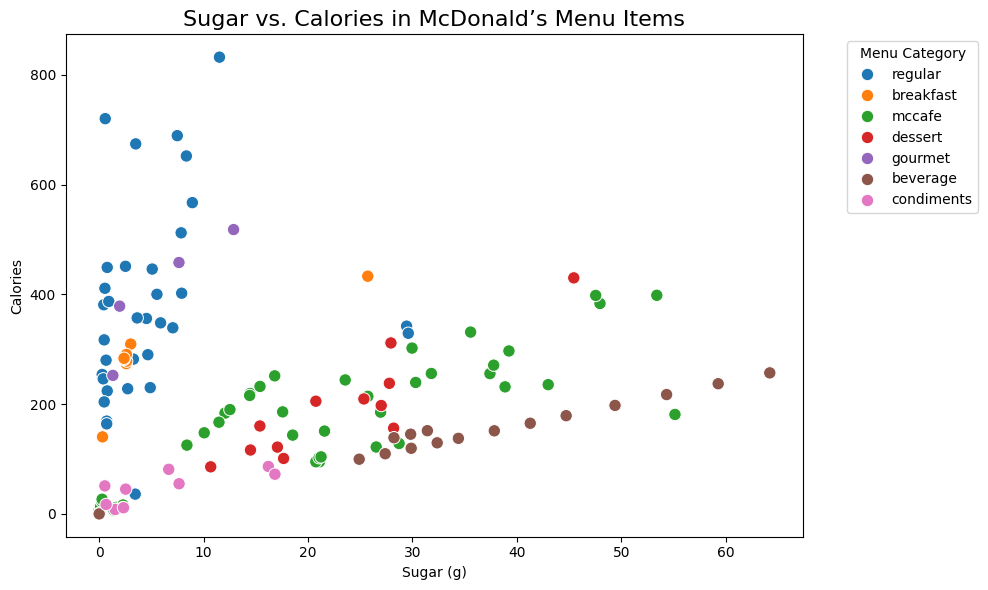

In [24]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=calorie_df,
    x='sugar',
    y='calories',
    hue='menu',
    s=80
)

plt.title('Sugar vs. Calories in McDonald’s Menu Items', fontsize=16)
plt.xlabel('Sugar (g)')
plt.ylabel('Calories')
plt.legend(title='Menu Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

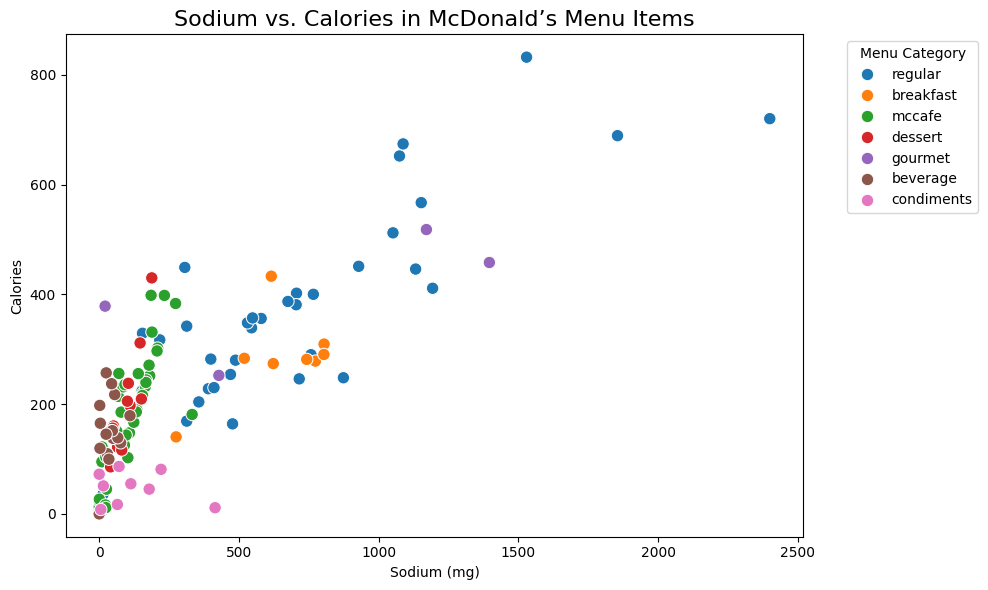

In [25]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=calorie_df,
    x='sodium',
    y='calories',
    hue='menu',
    s=80
)

plt.title('Sodium vs. Calories in McDonald’s Menu Items', fontsize=16)
plt.xlabel('Sodium (mg)')
plt.ylabel('Calories')
plt.legend(
    title='Menu Category',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

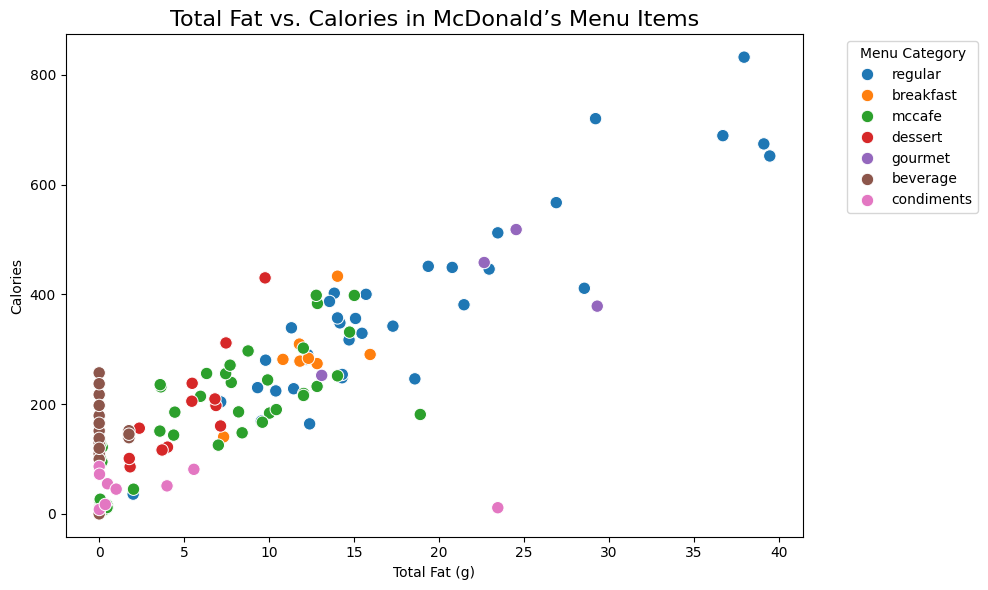

In [26]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=calorie_df,
    x='totalfat',
    y='calories',
    hue='menu',
    s=80
)

plt.title('Total Fat vs. Calories in McDonald’s Menu Items', fontsize=16)
plt.xlabel('Total Fat (g)')
plt.ylabel('Calories')
plt.legend(
    title='Menu Category',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

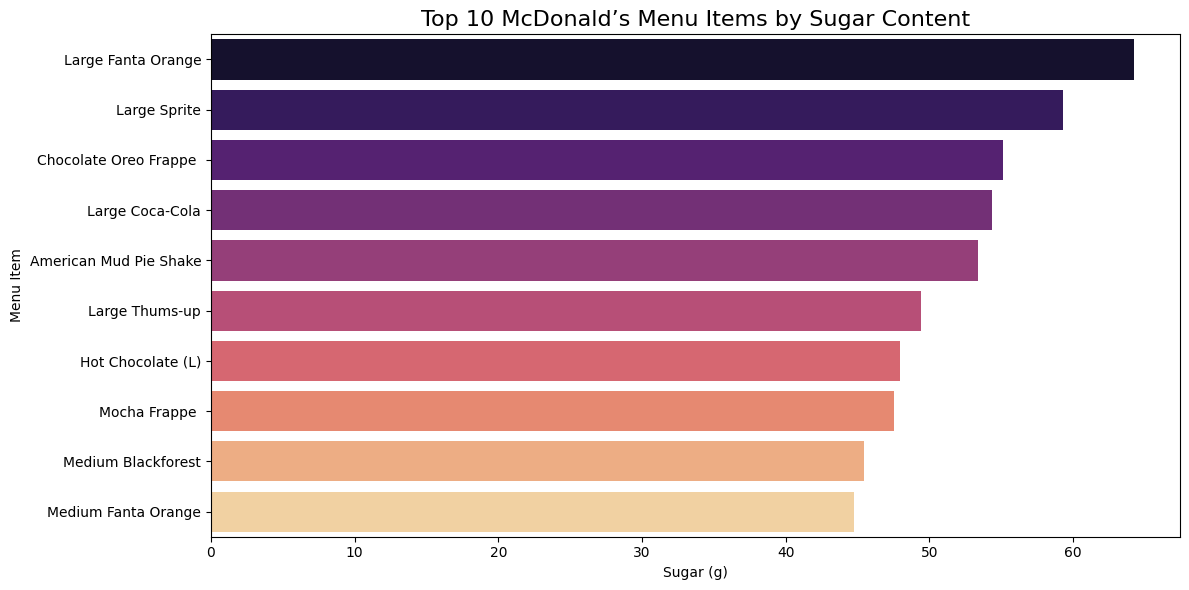

In [27]:
# Select top 10 items by sugar content
top_sugar = df.nlargest(10, 'sugar')

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_sugar,
    x='sugar',
    y='item',
    hue='item',
    palette='magma',
    legend=False
)

plt.title('Top 10 McDonald’s Menu Items by Sugar Content', fontsize=16)
plt.xlabel('Sugar (g)')
plt.ylabel('Menu Item')
plt.tight_layout()
plt.show()

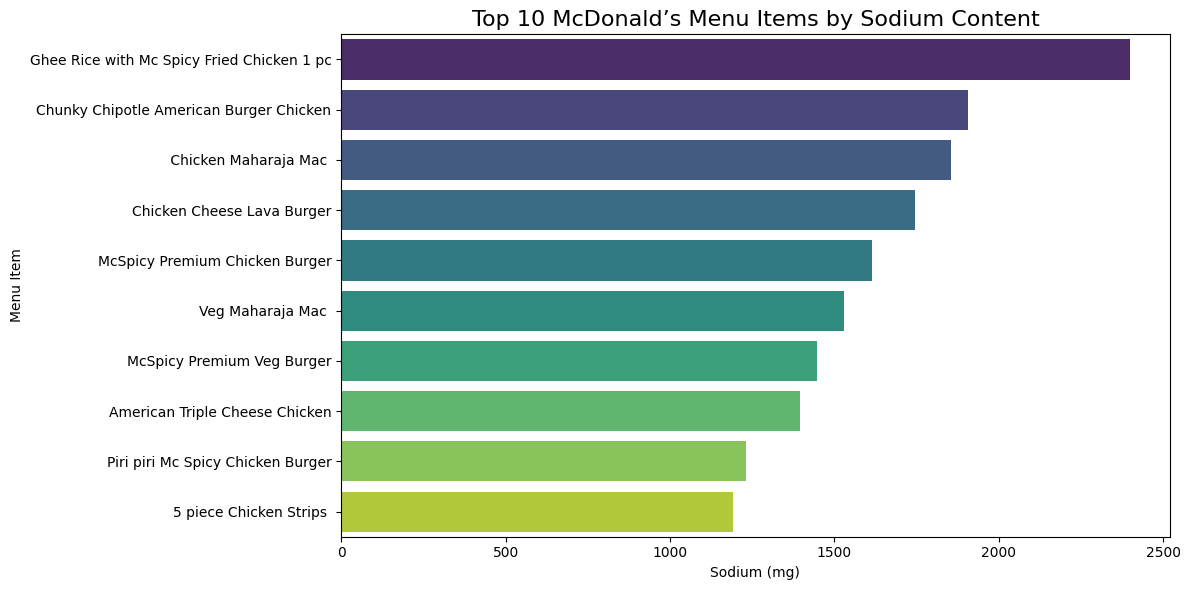

In [28]:
# Select top 10 items by sodium content
top_sodium = df.nlargest(10, 'sodium')

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_sodium,
    x='sodium',
    y='item',
    hue='item',
    palette='viridis',
    legend=False
)

plt.title('Top 10 McDonald’s Menu Items by Sodium Content', fontsize=16)
plt.xlabel('Sodium (mg)')
plt.ylabel('Menu Item')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1607/1981258034.py:18: UserWarning: Glyph 153 (\x99) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 153 (\x99) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


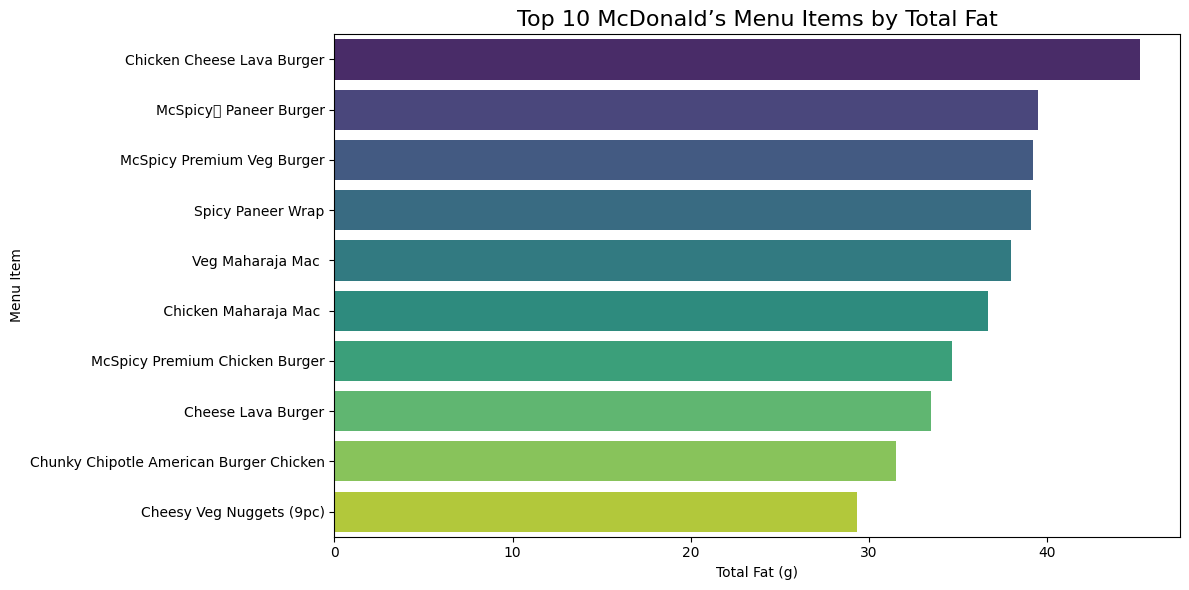

In [29]:
# Select top 10 items by total fat
top_fat = df.nlargest(10, 'totalfat')

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_fat,
    x='totalfat',
    y='item',
    hue='item',
    palette='viridis',
    legend=False
)

plt.title('Top 10 McDonald’s Menu Items by Total Fat', fontsize=16)
plt.xlabel('Total Fat (g)')
plt.ylabel('Menu Item')
plt.tight_layout()
plt.show()

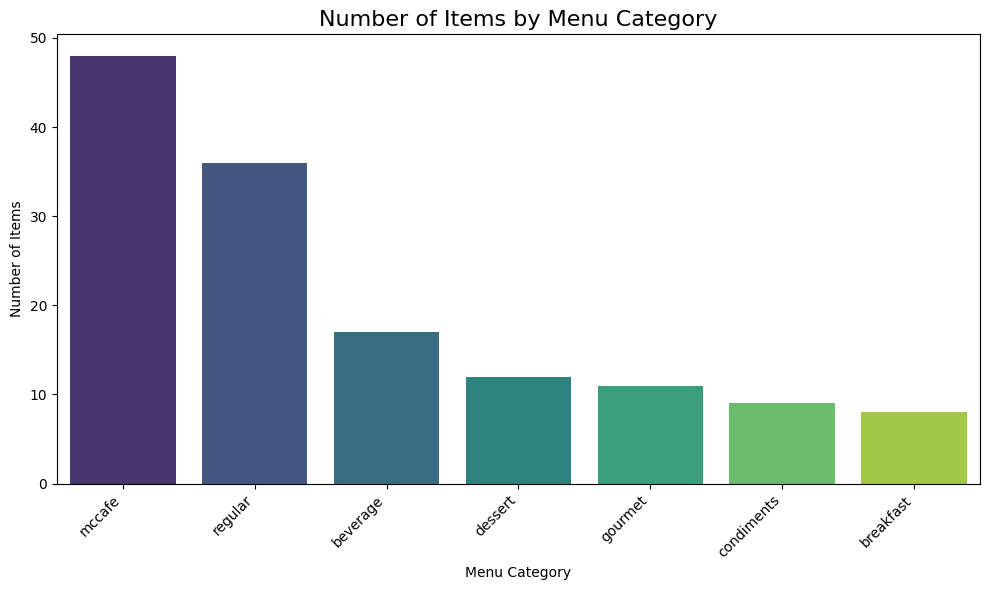

In [30]:
# Count items in each menu category
menu_counts = df['menu'].value_counts().reset_index()
menu_counts.columns = ['menu', 'count']

plt.figure(figsize=(10, 6))

sns.barplot(
    data=menu_counts,
    x='menu',
    y='count',
    hue='menu',
    palette='viridis',
    legend=False
)

plt.title('Number of Items by Menu Category', fontsize=16)
plt.xlabel('Menu Category')
plt.ylabel('Number of Items')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

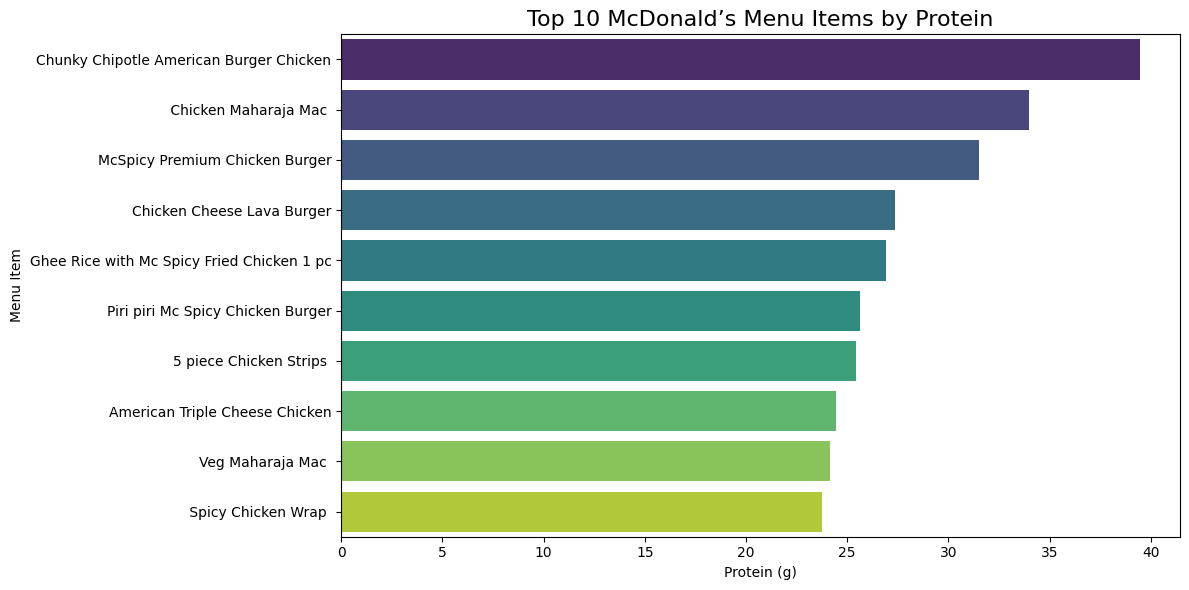

In [33]:
top_protein = df.nlargest(10, 'protein')

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_protein,
    x='protein',
    y='item',
    hue='item',
    palette='viridis',
    legend=False
)

plt.title('Top 10 McDonald’s Menu Items by Protein', fontsize=16)
plt.xlabel('Protein (g)')
plt.ylabel('Menu Item')
plt.tight_layout()
plt.show()

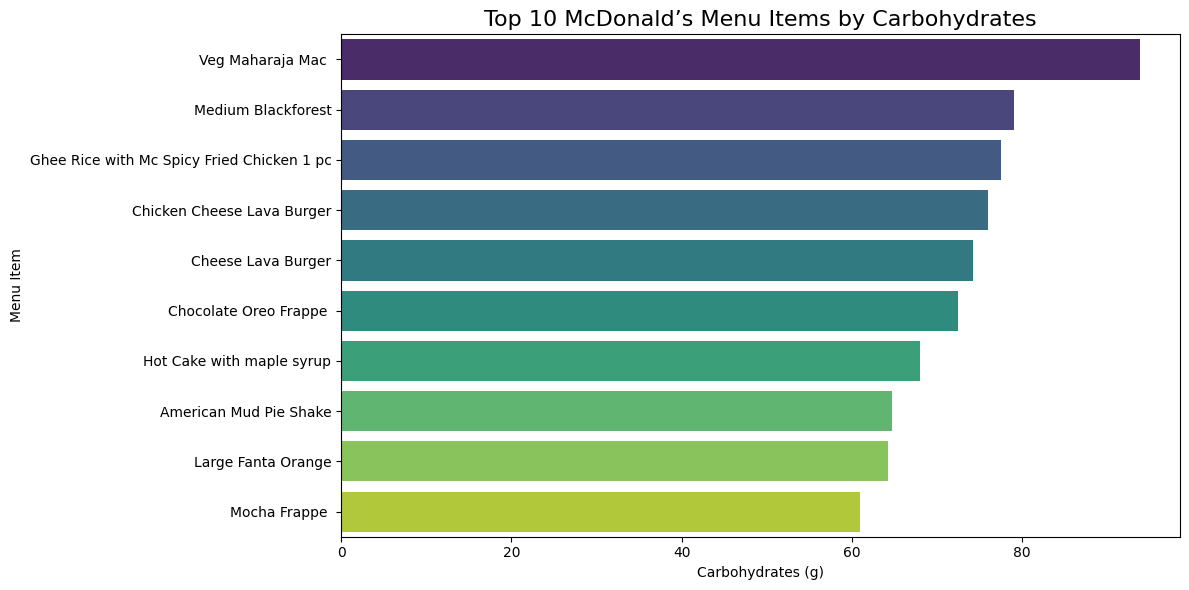

In [34]:
top_carbs = df.nlargest(10, 'carbs')

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_carbs,
    x='carbs',
    y='item',
    hue='item',
    palette='viridis',
    legend=False
)

plt.title('Top 10 McDonald’s Menu Items by Carbohydrates', fontsize=16)
plt.xlabel('Carbohydrates (g)')
plt.ylabel('Menu Item')
plt.tight_layout()
plt.show()

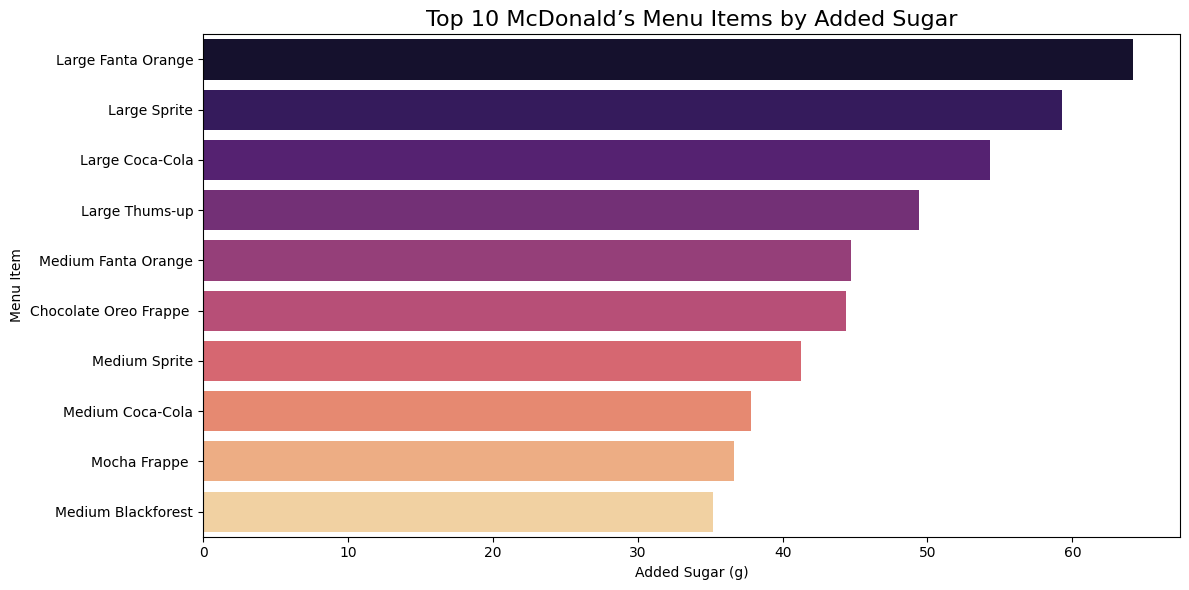

In [35]:
top_added_sugar = df.nlargest(10, 'addedsugar')

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_added_sugar,
    x='addedsugar',
    y='item',
    hue='item',
    palette='magma',
    legend=False
)

plt.title('Top 10 McDonald’s Menu Items by Added Sugar', fontsize=16)
plt.xlabel('Added Sugar (g)')
plt.ylabel('Menu Item')
plt.tight_layout()
plt.show()

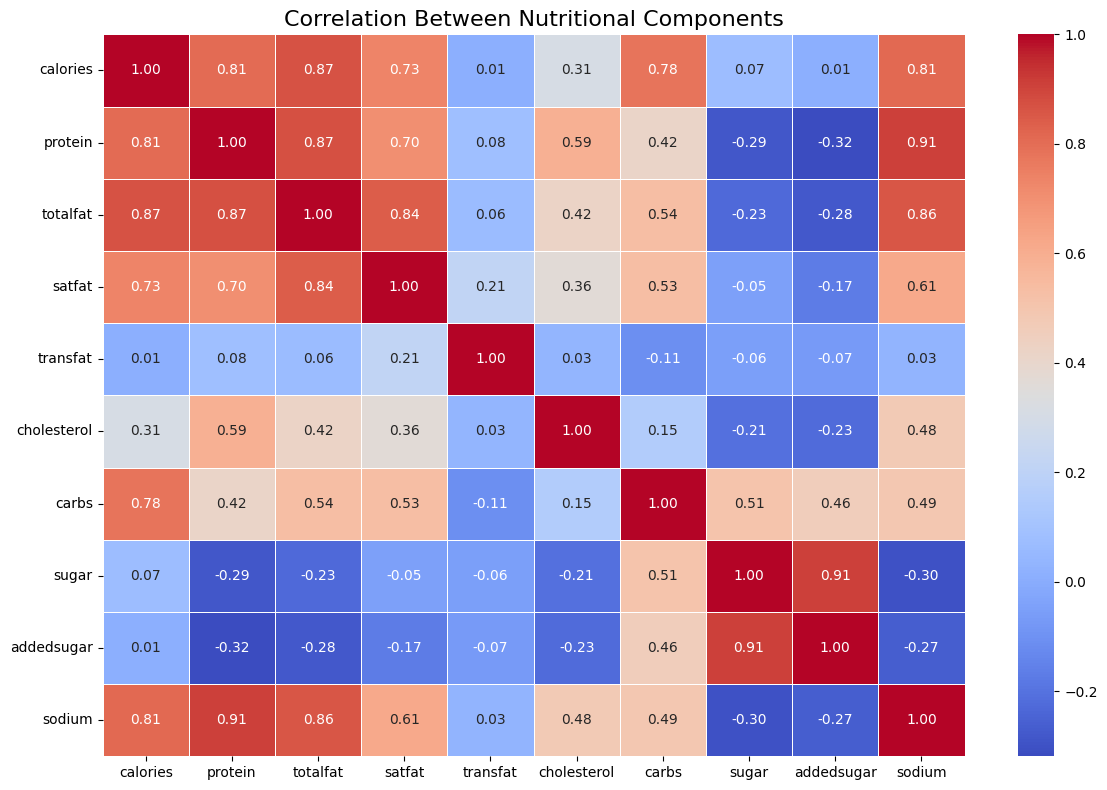

In [36]:
# Select numerical nutrition columns
numeric_cols = [
    'calories', 'protein', 'totalfat', 'satfat',
    'transfat', 'cholesterol', 'carbs', 'sugar',
    'addedsugar', 'sodium'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Between Nutritional Components', fontsize=16)
plt.tight_layout()
plt.show()

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
# Select numerical columns
columns = [
    'calories', 'protein', 'totalfat',
    'satfat', 'sugar', 'sodium'
]

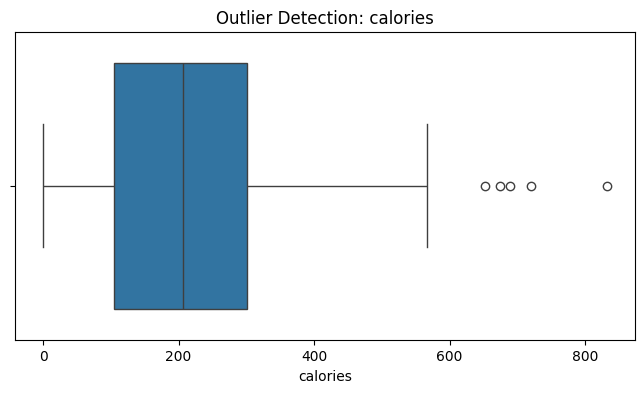

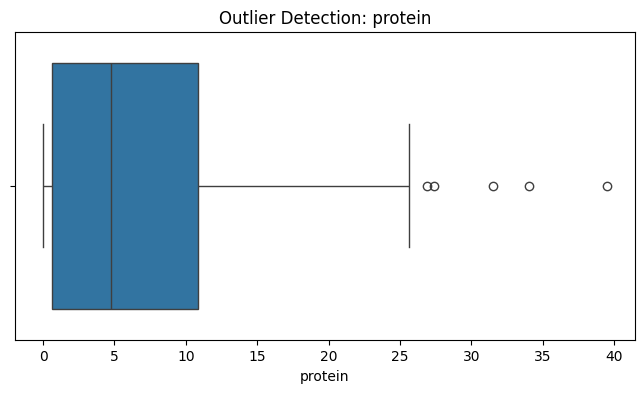

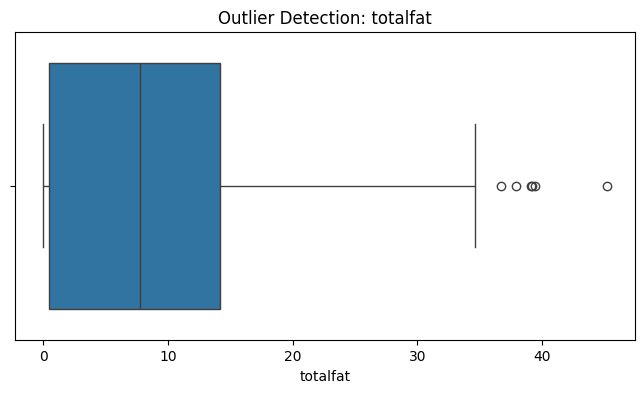

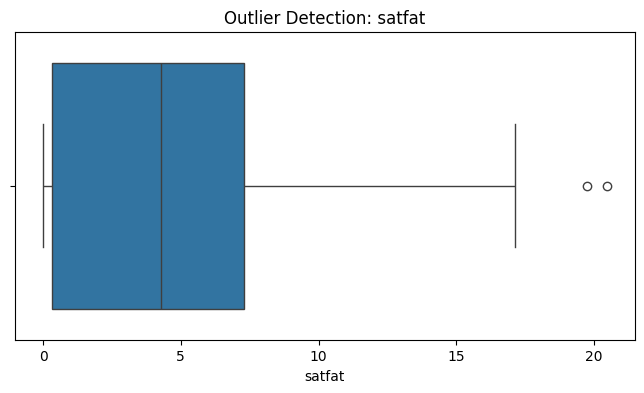

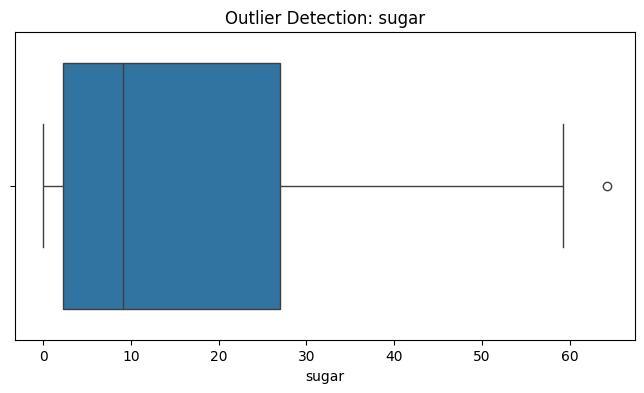

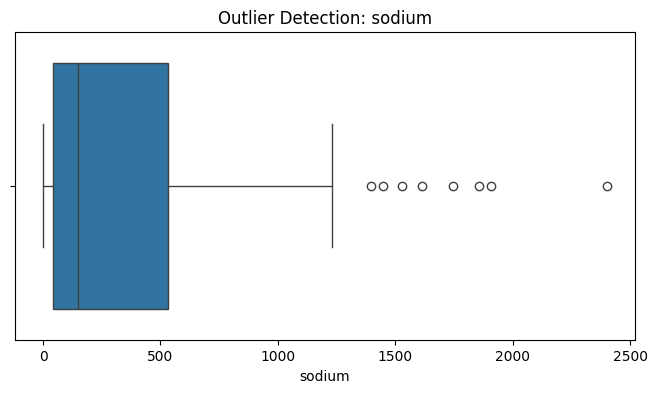

In [40]:
# Create boxplots
for col in columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Outlier Detection: {col}')
    plt.xlabel(col)
    plt.show()

In [41]:
# Detect outliers using IQR
for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ]

    print(f"\nColumn: {col}")
    print("Lower limit:", lower_limit)
    print("Upper limit:", upper_limit)
    print("Number of outliers:", len(outliers))



Column: calories
Lower limit: -187.88249999999996
Upper limit: 593.8774999999999
Number of outliers: 5

Column: protein
Lower limit: -14.695
Upper limit: 26.225
Number of outliers: 5

Column: totalfat
Lower limit: -20.089999999999996
Upper limit: 34.709999999999994
Number of outliers: 6

Column: satfat
Lower limit: -10.095
Upper limit: 17.705000000000002
Number of outliers: 2

Column: sugar
Lower limit: -34.724999999999994
Upper limit: 63.955
Number of outliers: 1

Column: sodium
Lower limit: -690.8349999999999
Upper limit: 1263.3649999999998
Number of outliers: 8


In [42]:
col = 'calories'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df[col] < lower_limit) |
    (df[col] > upper_limit)
]

print(outliers)

                                          item servesize  calories  protein  \
2                       McSpicy Paneer Burger      199      652.0    20.29   
3                            Spicy Paneer Wrap      250      674.0    20.96   
5                            Veg Maharaja Mac        306     832.0    24.17   
12                       Chicken Maharaja Mac      296       689.0    34.00   
18  Ghee Rice with Mc Spicy Fried Chicken 1 pc       325     720.0    26.91   

    totalfat  satfat  transfat  cholesterol  carbs  sugar  addedsugar  \
2      39.45   17.12      0.18        21.85  52.33   8.35        5.27   
3      39.10   19.73      0.26        40.93  59.27   3.50        1.08   
5      37.94   16.83      0.28        36.19  93.84  11.52        6.92   
12     36.69   10.33      0.25        81.49  55.39   7.48        6.14   
18     29.20    5.08      0.30        31.32  77.47   0.58        0.35   

     sodium     menu  
2   1074.58  regular  
3   1087.46  regular  
5   1529.22  regu

In [43]:
results = []

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    count = (
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ).sum()

    results.append({
        'Variable': col,
        'Outlier Count': count,
        'Outlier Percentage': round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(results)
print(outlier_summary)

   Variable  Outlier Count  Outlier Percentage
0  calories              5                3.55
1   protein              5                3.55
2  totalfat              6                4.26
3    satfat              2                1.42
4     sugar              1                0.71
5    sodium              8                5.67


Outlier Detection – Observation

Outlier detection was performed using boxplots and the Interquartile Range (IQR) method. The lower and upper limits were calculated using 1.5 times the IQR. Observations outside these limits were identified as potential outliers.

The analysis helps identify unusually high or low nutritional values in variables such as calories, protein, total fat, sugar, and sodium. These observations should be investigated to determine whether they represent genuine nutritional variation, data entry errors, or other data quality issues.

Conclusion: Potential outliers should be examined before deciding whether to retain, transform, or remove them.

In [44]:
import pandas as pd
from scipy.stats import pearsonr

# Remove missing values
data = df[['calories', 'totalfat']].dropna()

# Perform Pearson correlation test
r, p_value = pearsonr(
    data['calories'],
    data['totalfat']
)

print("Correlation coefficient:", r)
print("P-value:", p_value)

# Set significance level
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis (H0).")
    print("There is a statistically significant relationship.")
else:
    print("Fail to reject the null hypothesis (H0).")
    print("There is insufficient evidence of a significant relationship.")

Correlation coefficient: 0.8696282705479105
P-value: 2.7441773131738897e-42
Reject the null hypothesis (H0).
There is a statistically significant relationship.


Hypothesis Testing – Conclusion

A Pearson correlation test was conducted to examine the relationship between calories and total fat. The correlation coefficient was 0.8696, indicating a strong positive correlation. The p-value was 2.74 × 10⁻⁴², which is less than the significance level of 0.05.

Therefore, the null hypothesis was rejected, and the alternative hypothesis was accepted as supported by the evidence. The results indicate a statistically significant positive linear relationship between calories and total fat. This suggests that foods with higher total fat content tend to have higher calorie content.